In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Aufgabe 1: Tokenization

Neuronale Netze erwarten numerische Werte (Vektoren oder Matrizen) als Inputdaten, allerdings sind Texte nicht numerisch. Entsprechend müssen Texte in eine numerische Repräsentation umgewandelt werden. Hierfür wird die Tokenization verwendet. Dabei wird der Text in einzelne Wörter oder Zeichen zerlegt, die als Token bezeichnet werden. Jedes Token wird dann in eine numerische Repräsentation umgewandelt, die als Embedding bezeichnet wird. Die Embeddings werden in einer Embedding-Tabelle gespeichert, die den Token-IDs zugeordnet sind.

In [2]:
txt_data = "Blaukraut bleibt Blaukraut und Brautkleid bleibt Brautkleid."

Einfachste Möglichkeit der Encodierung -> `Binary-Encoding`:

In [3]:
" ".join(format(ord(c), "08b") for c in txt_data)

'01000010 01101100 01100001 01110101 01101011 01110010 01100001 01110101 01110100 00100000 01100010 01101100 01100101 01101001 01100010 01110100 00100000 01000010 01101100 01100001 01110101 01101011 01110010 01100001 01110101 01110100 00100000 01110101 01101110 01100100 00100000 01000010 01110010 01100001 01110101 01110100 01101011 01101100 01100101 01101001 01100100 00100000 01100010 01101100 01100101 01101001 01100010 01110100 00100000 01000010 01110010 01100001 01110101 01110100 01101011 01101100 01100101 01101001 01100100 00101110'

Problem des `Binary-Encodings`:
- sehr lange Sequenzen und nur sehr geringe Anzahl an möglichen Tokens (0 und 1)

Verbesserung: `UTF-8-Encoding`:
- Verwendung von 8-Bit-Encodings
- Reduzierung der Länge der Sequenzen um den Faktor 8

In [4]:
tokens = list(txt_data.encode("utf-8"))
" ".join(str(i) for i in tokens)

'66 108 97 117 107 114 97 117 116 32 98 108 101 105 98 116 32 66 108 97 117 107 114 97 117 116 32 117 110 100 32 66 114 97 117 116 107 108 101 105 100 32 98 108 101 105 98 116 32 66 114 97 117 116 107 108 101 105 100 46'

Weitere Verbesserung:

`Byte-Pair-Encoding (BPE)`:
- Idee: Mergen von häufigen Token-Paaren zu einem neuen Token (z.b. Token 255 und 256 -> Token 257)
- Wiederholen des Mergens bis eine bestimmte Anzahl an Tokens erreicht ist
- Basis: UTF-8-Encoding

a) Implementiere eine Funktion `get_stats(tokens: list[int]) -> dict[tuple[int, int], int]`, die eine Liste von Token als Input erhält und die Häufigkeit der aufeinanderfolgenden Token-Paaren zurückgibt. Der Rückgabewert ist ein Dictionary mit den Token-Paaren als Schlüssel und der Häufigkeit als Wert. 
Berechne anschließend die Häufigkeiten in den Tokens mit der Funktion.

In [11]:
def get_stats(tokens: list[int]) -> dict[tuple[int, int], int]:
    
    count = {}

    for i in range(len(tokens) - 1):
        pair = (tokens[i], tokens[i+1])
        count[pair] = count.get(pair, 0) + 1
    return count

In [12]:
stats = get_stats(tokens)
print(stats)

{(66, 108): 2, (108, 97): 2, (97, 117): 6, (117, 107): 2, (107, 114): 2, (114, 97): 4, (117, 116): 4, (116, 32): 4, (32, 98): 2, (98, 108): 2, (108, 101): 4, (101, 105): 4, (105, 98): 2, (98, 116): 2, (32, 66): 3, (32, 117): 1, (117, 110): 1, (110, 100): 1, (100, 32): 2, (66, 114): 2, (116, 107): 2, (107, 108): 2, (105, 100): 2, (100, 46): 1}


b) Finde das häufigste Token-Paar und printe es sowie dessen Häufigkeit als auch die String-Repräsentation des Token-Paares.

In [14]:
top_pair = max(stats, key=stats.get)
top_count = stats[top_pair]

In [15]:
top_pair_str = bytes(top_pair).decode("utf-8", errors="replace")

print(f"Häufigstes Paar: {top_pair}")
print(f"Häufigkeit: {top_count}")
print(f"String-Repräsentation: '{top_pair_str}'")

Häufigstes Paar: (97, 117)
Häufigkeit: 6
String-Repräsentation: 'au'


c) Was ist die ID des aktuell größtmöglichen Tokens?

255

d) Hier ist der Code für die Funktion `merge(ids: list[int], pair: tuple[int, int], idx: int) -> list[int]`, die ein Paar von Token in der Liste von Token-IDs zusammenführt. Die Funktion gibt die Liste der Token-IDs zurück, in der das Paar von Token zusammengeführt wurde. Der neue Token hat den Index `idx` erhalten. Teste die Funktion mit dem Paar von Token, das du in `b)` gefunden hast. Berechne die Compression Rate, die sich aus der Reduktion der Anzahl der Token ergibt.

In [19]:
def merge(ids: list[int], pair: tuple[int, int], idx: int) -> list[int]:
    """
    Merge a pair of tokens in the list of token ids.

    Parameters
    ----------
    ids : list[int]
        List of token ids.
    pair : tuple[int, int]
        Pair of token ids to merge.
    idx : int
        Index of the new token.

    Returns
    -------
    list[int]
        List of token ids with the pair of tokens merged.
    """
    newids = []
    i = 0
    while i < len(ids):
      if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
        newids.append(idx)
        i += 2
      else:
        newids.append(ids[i])
        i += 1
    return newids

In [27]:
new_token_id = 256

merged_tokens = merge(tokens, top_pair, new_token_id)

compression_rate = (len(tokens)-len(merged_tokens)) / len(tokens)

print(f"Ursprüngliche Token-Anzahl: {len(tokens)}")
print(f"Token-Anzahl nach Merge:    {len(merged_tokens)}")
print(f"Compression Rate:           {compression_rate}")
print(f"Neue Token-Liste:           {merged_tokens}")

Ursprüngliche Token-Anzahl: 60
Token-Anzahl nach Merge:    54
Compression Rate:           0.1
Neue Token-Liste:           [66, 108, 256, 107, 114, 256, 116, 32, 98, 108, 101, 105, 98, 116, 32, 66, 108, 256, 107, 114, 256, 116, 32, 117, 110, 100, 32, 66, 114, 256, 116, 107, 108, 101, 105, 100, 32, 98, 108, 101, 105, 98, 116, 32, 66, 114, 256, 116, 107, 108, 101, 105, 100, 46]


e) Implementiere mit Hilfe der obigen Funktionen den `Byte Pair Encoding Algorithmus` und wende ihn für `10` Iterationen auf die folgende Tokenliste an. Speichere zudem die erzeugten Merges als Dictionary `dict[tuple[int, int], int]` ab. Gebe am Ende die neuen Tokens und die Kompressionsrate aus.

In [29]:
txt_data = "Blaukraut bleibt Blaukraut und Brautkleid bleibt Brautkleid."
tokens = list(txt_data.encode("utf-8"))

merges: dict[tuple[int, int], int] = {}

In [30]:
original_length = len(tokens)
num_iterations = 10

current_tokens = list(tokens)

for i in range(num_iterations):
    stats = get_stats(current_tokens)
    
    if not stats:
        break
        
    top_pair = max(stats, key=stats.get)
    
    new_idx = 256 + i
    
    current_tokens = merge(current_tokens, top_pair, new_idx)
    
    merges[top_pair] = new_idx
    
    print(f"Iteration {i+1}: Merge {top_pair} -> {new_idx} (Häufigkeit: {stats[top_pair]})")

Iteration 1: Merge (97, 117) -> 256 (Häufigkeit: 6)
Iteration 2: Merge (114, 256) -> 257 (Häufigkeit: 4)
Iteration 3: Merge (257, 116) -> 258 (Häufigkeit: 4)
Iteration 4: Merge (108, 101) -> 259 (Häufigkeit: 4)
Iteration 5: Merge (259, 105) -> 260 (Häufigkeit: 4)
Iteration 6: Merge (32, 66) -> 261 (Häufigkeit: 3)
Iteration 7: Merge (108, 256) -> 262 (Häufigkeit: 2)
Iteration 8: Merge (262, 107) -> 263 (Häufigkeit: 2)
Iteration 9: Merge (263, 258) -> 264 (Häufigkeit: 2)
Iteration 10: Merge (264, 32) -> 265 (Häufigkeit: 2)


In [34]:
compression_rate_n = (original_length-len(current_tokens)) / original_length

print(f"Neue Tokens:       {current_tokens}")
print(f"Anzahl Merges:     {len(merges)}")
print(f"Kompressionsrate:  {compression_rate_n:.4f}")

Neue Tokens:       [66, 265, 98, 260, 98, 116, 261, 265, 117, 110, 100, 261, 258, 107, 260, 100, 32, 98, 260, 98, 116, 261, 258, 107, 260, 100, 46]
Anzahl Merges:     10
Kompressionsrate:  0.5500


Das ist das initiale Vokabular, also das 'UTF-8' encoding der ersten 256 Charactere.

In [35]:
vocab: dict[int, str] = {i: chr(i) for i in range(256)}

f) Ergänze das Vokabular mit den gemergten Tokens. Gebe die Anzahl der Tokens im Vokabular aus.

In [36]:
vocab = {i: chr(i) for i in range(256)}

for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]

print(f"Anzahl der Tokens im Vokabular: {len(vocab)}")

for i in range(256, 256 + len(merges)):
    print(f"Token {i}: '{vocab[i]}'")

Anzahl der Tokens im Vokabular: 266
Token 256: 'au'
Token 257: 'rau'
Token 258: 'raut'
Token 259: 'le'
Token 260: 'lei'
Token 261: ' B'
Token 262: 'lau'
Token 263: 'lauk'
Token 264: 'laukraut'
Token 265: 'laukraut '


g) Implementiere jetzt eine Funktion `decode(ids: list[int], vocab: dict[int, str]) -> str`, die die Liste von Token-IDs in den ursprünglichen Text umwandelt.

In [39]:
def decode(ids: list[int], vocab: dict[int, str]) -> str:

    text_parts = [vocab[idx] for idx in ids]
    return "".join(text_parts)

In [40]:
# Zur Kontrolle
assert decode([83, 117, 99, 99, 101, 115, 115, 33], vocab) == "Success!"
print("Success!")

Success!


h) Optional: Implementiere eine Funktion `encode(text: str, vocab: dict[str, int]) -> list[int]`, die den Text in eine Liste von Token-IDs umwandelt. Beachte hierbei auch die gemergten Tokens.

In [41]:
def encode(txt: str, merges: dict[tuple[int, int], int]) -> list[int]:

    tokens = list(txt.encode("utf-8"))
    
    for pair, idx in merges.items():
        tokens = merge(tokens, pair, idx)
        
    return tokens

In [42]:
txt = "Blaukraut bleibt Blaukraut und Brautkleid bleibt Brautkleid."
assert decode(encode(txt, merges), vocab) == txt
print("Success!")

Success!


i) Teste anschließend die Bibliothek `tiktoken`, encodiere den Text `"Hello, World!"` und decodiere ihn anschließend wieder. Nutze hierfür den Tokenizer des GPT4 Base-Modelles (`"cl100k_base"`) Vergleiche den Output mit dem ursprünglichen Text.

In [47]:
# Install tiktoken
!pip install tiktoken

Defaulting to user installation because normal site-packages is not writeable


In [50]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

text_to_encode = "Hello, World!"
tokens = enc.encode(text_to_encode)

decoded_text = enc.decode(tokens)

print(f"Originaler Text: {text_to_encode}")
print(f"Token-IDs:       {tokens}")
print(f"Decodierter Text: {decoded_text}")

/Users/alimounir/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Originaler Text: Hello, World!
Token-IDs:       [9906, 11, 4435, 0]
Decodierter Text: Hello, World!


In [51]:
assert decoded_text == text_to_encode
print("Vergleich erfolgreich: Der Output entspricht dem ursprünglichen Text!")

Vergleich erfolgreich: Der Output entspricht dem ursprünglichen Text!


## Aufgabe 2. Token-Embedding

a) Implementiere eine Klasse `TokenEmbedding` mit Numpy. Die Klasse soll die Methoden `__init__(self, vocab_size: int, embedding_dim: int)` und `forward(self, x: np.ndarray) -> np.ndarray` implementieren. Die Methode `forward` soll die Embeddings für die Token-IDs berechnen und zurückgeben. Initialisiere die Embeddings als `numpy`-Array mit der Shape `(vocab_size, embedding_dim)`. Verwende eine Embedding-Dimension von `24` und eine Vokabulargröße entsprechend des zuvor trainierten Vokabulars.

In [52]:
class TokenEmbedding:
    
    def __init__(self, vocab_size: int, embedding_dim: int):

        self.embedding_table = np.random.randn(vocab_size, embedding_dim)
        
    def forward(self, x: np.ndarray) -> np.ndarray:

        return self.embedding_table[x]

In [53]:
vocab_size = len(vocab) 
embedding_dim = 24

token_embedding_table = TokenEmbedding(vocab_size, embedding_dim)

In [54]:
tokens = [1,2,3,4]
batched_tokens = np.array([tokens, tokens]) 
assert token_embedding_table.forward(batched_tokens).shape == (2, len(tokens), 24)
print("Success!")

Success!


## Aufgabe 3. Rekurrente Neuronale Netze für Sprachmodelle

a) Implementiere eine Funktion für die Berechnung der Softmax Verteilung `softmax(x: np.ndarray) -> np.ndarray`. Die Funktion soll die Softmax Verteilung für die Eingabe `x` berechnen und zurückgeben.

Wiederholung: Softmax Funktion:
$$ \text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}} $$


In [55]:
def softmax(x: np.ndarray) -> np.ndarray:

    e_x = np.exp(x - np.max(x))
    
    return e_x / e_x.sum(axis=-1, keepdims=True)

In [56]:
test_input = np.array([2.0, 1.0, 0.1])
output = softmax(test_input)

print(f"Eingabe:  {test_input}")
print(f"Softmax:  {output}")
print(f"Summe:    {np.sum(output)}")

batch_input = np.array([[1.0, 2.0], [3.0, 4.0]])
batch_output = softmax(batch_input)
print(f"Batch Summen: {batch_output.sum(axis=-1)}")

Eingabe:  [2.  1.  0.1]
Softmax:  [0.65900114 0.24243297 0.09856589]
Summe:    1.0
Batch Summen: [1. 1.]


b) Implementiere ein rekurrentes Neuronales Netzwerk in der Klasse `RNN` mit Numpy. Die Klasse soll die Methoden `__init__(self, input_dim: int, hidden_dim: int, output_dim: int)` und `forward(self, x: np.ndarray) -> np.ndarray` enthalten. Die Methode `forward` soll die Vorhersage für das nächste Token berechnen und zurückgeben. Hierbei ist `x` die Sequenz der Embeddings aus der Token-Embedding Tabelle. Initialisiere die Gewichte für die Input-to-Hidden, Hidden-to-Hidden und Hidden-to-Output Matrizen mit der `He-Initialization`. Ziel der `He-Initialization` ist es, die Aktivierungen in einem Bereich zu halten, in dem die Ableitung der Aktivierungsfunktion nicht zu klein ist. Die Varianz der Gewichte wird dabei mit `2/n` initialisiert, wobei `n` die Anzahl der Inputs ist. 
Initialisiere `Bias`-Werte im folgenden immer mit `0`. Initialisiere die Hidden-States mit `0`. Teste anschließend das `RNN` mit dem Kontroll-Code unten.

![rnn](rnn.png)

Hinweis: Das `RNN` muss nur für eine Batchsize von `1` funktionieren.

In [57]:
embed = token_embedding_table.forward(np.array([[1,2,3,4]]))

In [58]:
class RNN:
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        self.hidden_dim = hidden_dim
        
        self.Wxh = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim)
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.Why = np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        
        self.bh = np.zeros((hidden_dim, 1))
        self.by = np.zeros((output_dim, 1))

    def forward(self, x: np.ndarray) -> np.ndarray:
        x_seq = x[0] 
        
        h = np.zeros((self.hidden_dim, 1))
        
        for xt in x_seq:
            xt = xt.reshape(-1, 1)
            
            h = np.tanh(np.dot(self.Wxh, xt) + np.dot(self.Whh, h) + self.bh)
        
        y = np.dot(self.Why, h) + self.by
        
        return y.flatten()

In [60]:
rnn = RNN(input_dim=24, hidden_dim=64, output_dim=len(vocab))
output = rnn.forward(embed)
assert output.shape == (len(vocab), )
print("Success!")

Success!


c) Implementiere eine Funktion `generate_txt`, die das `RNN` und die `TokenEmbedding` Klasse nutzt, um einen neuen Text zu generieren. Generiere `10` weitere Tokens für den Input Text `"Hello, World!"` und gebe den generierten Text aus.

Hinweis: Der Text wird keinen Sinn ergeben, da das Netz nicht trainiert wurde.

In [61]:
def generate_txt(model, token_embeddings: TokenEmbedding, text: str, merges: dict[tuple[int, int], int], vocab: dict[int, str], new_tokens: int) -> str:

    input_ids = encode(text, merges)
    
    generated_text = text
    
    for _ in range(new_tokens):
        input_array = np.array([input_ids])
        embeddings = token_embeddings.forward(input_array)
        
        logits = model.forward(embeddings)
        
        probs = softmax(logits)
        
        next_token_id = np.random.choice(len(probs), p=probs)
        
        input_ids.append(next_token_id)
        
        generated_text += decode([next_token_id], vocab)
        
    return generated_text

In [65]:
input_bsp = "Hello, World!"

generated_output = generate_txt(
    model=rnn, 
    token_embeddings=token_embedding_table, 
    text=input_bsp, 
    merges=merges, 
    vocab=vocab, 
    new_tokens=10
)

print(f"Generierter Text:\n{generated_output}")

Generierter Text:
Hello, World!WªgqaÝ¡C


## Aufgabe 4: Self Attention

In dieser Aufgabe soll ein Self-Attention Block eines Transformers mit `numpy` implementiert werden. 
Verwende erneut die `He-Initialization` für die Initialisierung der Gewichte und `0` für die Bias-Werte.
Gehe davon, aus dass immer nur eine Batchsize von `1` betrachtet wird. Eine Erklärung der Attention und der benötigten Matrizen ist in den Folien der Vorlesung zu LLMs auf Seite 28 und 29.

a) Implementiere Self-Attention (keine Multi-Head Attention) und teste die Klasse mit dem Code unten.

In [68]:
class SelfAttention:
    
    def __init__(self, embed_size: int):
        self.embed_size = embed_size
        
        scale = np.sqrt(2.0 / embed_size)
        
        self.Wq = np.random.randn(embed_size, embed_size) * scale
        self.Wk = np.random.randn(embed_size, embed_size) * scale
        self.Wv = np.random.randn(embed_size, embed_size) * scale
        
        self.bq = np.zeros((1, embed_size))
        self.bk = np.zeros((1, embed_size))
        self.bv = np.zeros((1, embed_size))


        
    def forward(self, x: np.ndarray) -> np.ndarray:        
        Q = np.dot(x, self.Wq) + self.bq
        K = np.dot(x, self.Wk) + self.bk
        V = np.dot(x, self.Wv) + self.bv
        
        scores = np.dot(Q, K.T) / np.sqrt(self.embed_size)
        
        attn_weights = softmax(scores)
        
        output = np.dot(attn_weights, V)
        
        return output

In [69]:
attn = SelfAttention(embed_size=24)
embed = np.random.normal(size=(10, 24))
output = attn.forward(embed)
assert output.shape == (10, 24)
print("Success!")

Success!


b) Nenne die Vorteile und Nachteile der Self-Attention bei der Verarbeitung von Sprache mit LLMs:

+ Schneller auf GPUs, weil gesamte Sequenz auf einmal berechnet werden kann (parallel und nicht sequentiell)
+ Berücksichtigung des Kontexts für jedes Wort (Mehrdeutigkeit)
- Sehr komplex (O(N^2)), da jedes Token mit jedem anderen verglichen wird, wächst der Rechenbedarrf quadratisch mit der Länge des Textes
- Transformer brauchen meitens mehr Trainingsdaten als einfache Modelle, um gut zu generalisieren

## Aufgabe 4: Training eines LSTM

Der folgende Code erzeugt einen sehr einfachen Datensatz, in dem eine Sinus-Funktion approximiert werden soll.

In [71]:
def generate_sine_wave(samples=1000, timesteps=10):
    x = np.linspace(0, 100, samples)
    y = np.sin(x)
    X, Y = [], []
    
    for i in range(len(y) - timesteps):
        X.append(y[i:i + timesteps]) 
        Y.append(y[i + timesteps])
    
    return np.array(X).reshape(-1, timesteps, 1), np.array(Y).reshape(-1, 1)

X_train, y_train = generate_sine_wave(1000)
X_test, y_test = generate_sine_wave(100)

a) Trainiere ein LSTM Netzwerk von Keras auf den generierten Daten. Verwende eine Hidden-Dimension von `64` und trainiere das Netzwerk für `10` Epochen mit einer Batchsize von `32`. Verwende den Adam-Optimizer mit einer Lernrate von `0.01`. Das Modell soll aus einem LSTM Layer und einem Linear Layer bestehen.

In [72]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    tf.keras.layers.Input(shape=(10, 1)),
    LSTM(64),
    Dense(1)
])

optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse')

history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    verbose=1)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1211 - val_loss: 1.5929
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 1.7056
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0985e-05 - val_loss: 1.7079
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1800e-05 - val_loss: 1.7243
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6480e-06 - val_loss: 1.7381
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9837e-06 - val_loss: 1.7504
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9549e-06 - val_loss: 1.7590
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0595e-06 - val_loss: 1.7644
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8423e-07 - val_loss: 1.7666
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9393e-07 - val_loss: 1.7674


b) Plotte den Fit des Modells auf den Trainingsdaten und den Testdaten. Was fällt dir auf? Was könnte die Ursache für das Verhalten sein?

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


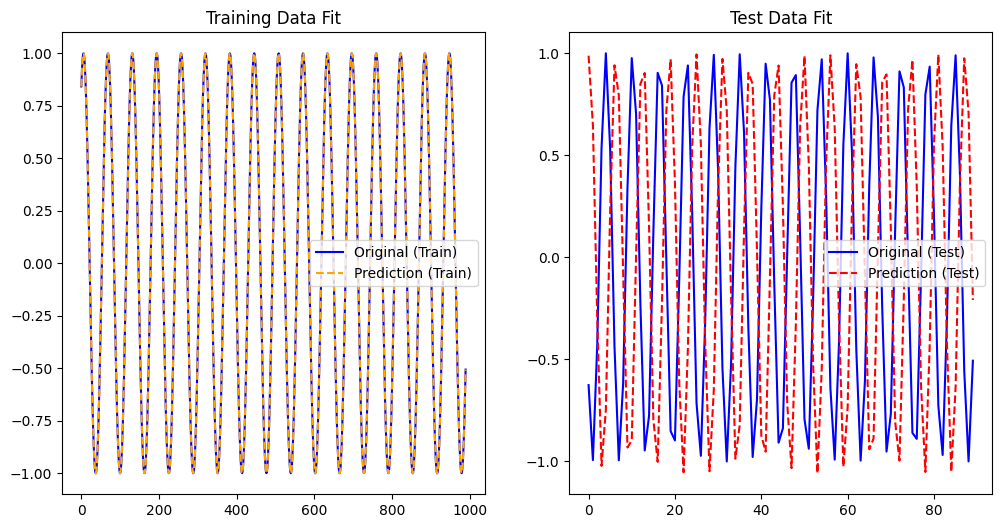

In [73]:
import matplotlib.pyplot as plt

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Training Data Fit")
plt.plot(y_train, label="Original (Train)", color='blue')
plt.plot(train_predictions, label="Prediction (Train)", color='orange', linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Test Data Fit")
plt.plot(y_test, label="Original (Test)", color='blue')
plt.plot(test_predictions, label="Prediction (Test)", color='red', linestyle='--')
plt.legend()

plt.show()

Antwort: Das Modell hat die Trainingsdaten perfekt gelernt (Overfitting). Im Test-Plot erkennet man, dass das Modell die Sinus-Form und die Amplitude beibehält, die Preditction jedoch fast exakt um eine halbe Periode phasenverschoben ist.
Ursache: Das LSTM denkt es sei bereits an einem anderen Punkt der Sinuskurve, was zur Verschiebung führt. Das Modell versucht, die gelernten zeitlichen Schritte auf eine Skala anzuwenden die nicht mehr wie im Training ist.